# 3D-Unet supervised wit zarr

Try out training a 3dunet (supervised) with a zarr data loader using the SELMA3D dataset

I use a pytorch 3dunet implementation 

### Preparation and Testing 

The data that im using for the tryouts is the 3DNucleiTracingData. The data was created and curated by the developer of the NuMorph toolkit at the Stein lab. \
i will use now only the c075 datasets that contain training , label and validation splits of high resolution image patches. 

In [30]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import h5py


In [31]:
base_path = '/mnt/ssd/lsm_training_data'

In [32]:
c075_cen = nib.load(base_path + '/c075_cen_final_224_64/c0101_Training-Side3-[00x01].nii')
c075_img = nib.load(base_path + '/c075_images_final_224_64/c0101_Training-Side3-[00x01].nii')


c075_cen_data = c075_cen.get_fdata().astype(np.float32)
c075_img_data = c075_img.get_fdata().astype(np.float32)

In [33]:
# image dimensions
print("Centrally Cropped Image Dimensions:", c075_cen_data.shape)
print("Original Image Dimensions:", c075_img_data.shape)


Centrally Cropped Image Dimensions: (224, 224, 64)
Original Image Dimensions: (224, 224, 64)


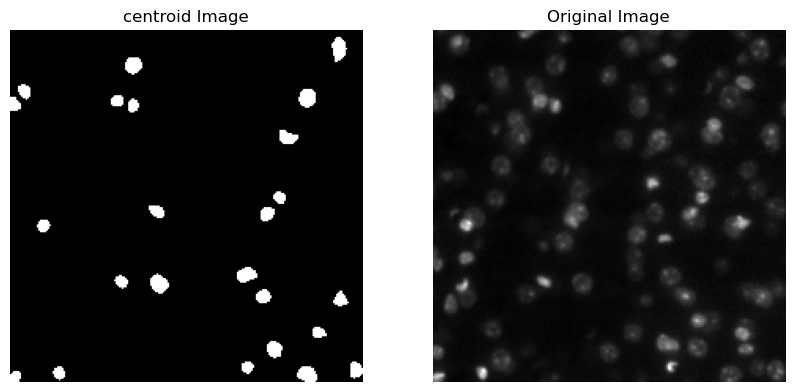

In [34]:

# show both images side by side 
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(c075_cen_data[:, :, c075_cen_data.shape[2] // 2], cmap='gray')
plt.title('centroid Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(c075_img_data[:, :, c075_img_data.shape[2] // 2], cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.show()

c075_cen: labled data \
c075_images: unlabled data 


In [35]:
# convert to hdf5

with h5py.File('c075_data.h5', 'w') as f:
    f.create_dataset('c075_cen_c0101', data=c075_cen_data)
    
    

OSError: Unable to synchronously create file (unable to truncate a file which is already open)

In [ ]:
file = h5py.File('c075_data.h5', 'r')
list(file.keys())

['c075_cen_c0101']

In [ ]:
dset = file['c075_cen_c0101']
dset.shape

(224, 224, 64)

Now test the unet package and training stuff
